# Parkinson's UPDRS Prediction — Model Building

**Task:** Multi-output Regression — predict `motor_UPDRS` and `total_UPDRS` simultaneously.

**Pipeline:**
1. Load preprocessed data
2. Baseline: Ridge / Lasso
3. SVR (RBF kernel)
4. Random Forest
5. Gradient Boosting (XGBoost)
6. MLP (Neural Network)
7. Model comparison + Feature Importance
8. Residual analysis & inference on test set

## 0. Setup

In [1]:
# !pip install -q ucimlrepo xgboost

In [18]:
import warnings
import pickle
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform, pearsonr

from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

PALETTE = sns.color_palette("muted")
SEED = 42
print("Imports OK")

Imports OK


## 1. Load Preprocessed Data

In [3]:
data = pd.read_csv("preprocessed_data.csv")
data = data.rename(columns={
    "Unnamed: 0": "subject#",
    "Jitter(avg)": "Jitter_avg",
    "Shimmer(avg)": "Shimmer_avg",
})

TARGETS = ["motor_UPDRS", "total_UPDRS"]
features = [c for c in data.columns if c not in TARGETS + ["subject#"]]

X = data[features]
y = data[TARGETS]

# Group-aware split to prevent data leakage across subjects
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=data["subject#"]))

X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=features)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),  columns=features)

train_subjects = data.iloc[train_idx]["subject#"].values

# Numpy arrays for sklearn helpers
X_tr_arr = X_train.values
y_tr_arr = y_train.values

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features: {features}")

Train: (4700, 9) | Test: (1175, 9)
Features: ['age', 'test_time', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE', 'Jitter_avg', 'Shimmer_avg']


## 2. Helper Functions

In [4]:
def evaluate(y_true, y_pred, split="Test"):
    """Compute RMSE, MAE, R², MAPE and Pearson-r for both targets."""
    results = {}
    for i, col in enumerate(TARGETS):
        yt = y_true.iloc[:, i] if hasattr(y_true, "iloc") else y_true[:, i]
        yp = y_pred[:, i] if y_pred.ndim == 2 else y_pred
        results[col] = {
            "RMSE":      np.sqrt(mean_squared_error(yt, yp)),
            "MAE":       mean_absolute_error(yt, yp),
            "R²":        r2_score(yt, yp),
            "MAPE":      mean_absolute_percentage_error(yt, yp),
            "Pearson_r": pearsonr(yt, yp)[0],
        }
    df_res = pd.DataFrame(results).T
    print(f"\n── {split} Set ──")
    print(df_res.round(4))
    return df_res


def cv_score(model, X, y, groups, n_splits=5, label=""):
    """GroupKFold cross-validation — returns mean RMSE and R² per target."""
    gkf = GroupKFold(n_splits=n_splits)
    rmse_motor, rmse_total, r2_motor, r2_total = [], [], [], []

    for tr, val in gkf.split(X, y, groups):
        model.fit(X[tr], y[tr])
        pred = model.predict(X[val])
        rmse_motor.append(np.sqrt(mean_squared_error(y[val, 0], pred[:, 0])))
        rmse_total.append(np.sqrt(mean_squared_error(y[val, 1], pred[:, 1])))
        r2_motor.append(r2_score(y[val, 0], pred[:, 0]))
        r2_total.append(r2_score(y[val, 1], pred[:, 1]))

    print(f"\n{'='*50}")
    print(f"[{label}] GroupKFold CV ({n_splits} folds)")
    print(f"  motor_UPDRS — RMSE: {np.mean(rmse_motor):.4f} ± {np.std(rmse_motor):.4f}  |  R²: {np.mean(r2_motor):.4f}")
    print(f"  total_UPDRS — RMSE: {np.mean(rmse_total):.4f} ± {np.std(rmse_total):.4f}  |  R²: {np.mean(r2_total):.4f}")

    return {
        "motor_RMSE": np.mean(rmse_motor), "total_RMSE": np.mean(rmse_total),
        "motor_R2":   np.mean(r2_motor),   "total_R2":   np.mean(r2_total),
    }


# Accumulators
cv_results   = {}
test_results = {}
print("Helpers ready.")

Helpers ready.


## 3. Baseline: Ridge & Lasso

Ridge uses L2 regularization — well-suited when multicollinearity is present.  
Lasso uses L1 — can zero out features, useful for implicit feature selection.

In [5]:
# Ridge — baseline (alpha=1) and auto-tuned via RidgeCV
ridge_base = MultiOutputRegressor(Ridge(alpha=1.0), n_jobs=-1)
cv_results["Ridge_Baseline"] = cv_score(ridge_base, X_tr_arr, y_tr_arr, train_subjects, label="Ridge Baseline")
ridge_base.fit(X_tr_arr, y_tr_arr)
test_results["Ridge_Baseline"] = evaluate(y_test, ridge_base.predict(X_test.values), "Ridge Baseline")

ridge_cv = MultiOutputRegressor(RidgeCV(alphas=np.logspace(-3, 3, 10)), n_jobs=-1)
cv_results["Ridge_Tuned"] = cv_score(ridge_cv, X_tr_arr, y_tr_arr, train_subjects, label="Ridge Tuned")
ridge_cv.fit(X_tr_arr, y_tr_arr)
test_results["Ridge_Tuned"] = evaluate(y_test, ridge_cv.predict(X_test.values), "Ridge Tuned")


[Ridge Baseline] GroupKFold CV (5 folds)
  motor_UPDRS — RMSE: 7.5726 ± 0.0381  |  R²: 0.1393
  total_UPDRS — RMSE: 9.8449 ± 0.0511  |  R²: 0.1599

── Ridge Baseline Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 7.5689 6.4412 0.1025 0.3902     0.3265
total_UPDRS 9.7621 8.1517 0.1400 0.3507     0.3771

[Ridge Tuned] GroupKFold CV (5 folds)
  motor_UPDRS — RMSE: 7.5725 ± 0.0364  |  R²: 0.1393
  total_UPDRS — RMSE: 9.8454 ± 0.0489  |  R²: 0.1598

── Ridge Tuned Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 7.5648 6.4414 0.1034 0.3905     0.3271
total_UPDRS 9.7585 8.1504 0.1406 0.3510     0.3774


In [6]:
# Lasso — find best alpha per target, then fit a shared model
lasso_cv_motor = LassoCV(cv=5, random_state=SEED).fit(X_tr_arr, y_tr_arr[:, 0])
lasso_cv_total = LassoCV(cv=5, random_state=SEED).fit(X_tr_arr, y_tr_arr[:, 1])
best_alpha = max(lasso_cv_motor.alpha_, lasso_cv_total.alpha_)
print(f"Best alpha — motor: {lasso_cv_motor.alpha_:.4f}  |  total: {lasso_cv_total.alpha_:.4f}  |  chosen: {best_alpha:.4f}")

lasso = MultiOutputRegressor(Lasso(alpha=best_alpha), n_jobs=-1)
cv_results["Lasso"] = cv_score(lasso, X_tr_arr, y_tr_arr, train_subjects, label="Lasso")
lasso.fit(X_tr_arr, y_tr_arr)
test_results["Lasso"] = evaluate(y_test, lasso.predict(X_test.values), "Lasso")

# Coefficient inspection
coef_df = pd.DataFrame({
    "feature":     X_train.columns,
    "coef_motor":  lasso.estimators_[0].coef_,
    "coef_total":  lasso.estimators_[1].coef_,
})
print("\n── Lasso coefficients (sorted by |motor coef|) ──")
print(coef_df.sort_values("coef_motor", key=abs, ascending=False).to_string(index=False))

Best alpha — motor: 0.3961  |  total: 1.4428  |  chosen: 1.4428

[Lasso] GroupKFold CV (5 folds)
  motor_UPDRS — RMSE: 7.9733 ± 0.0184  |  R²: 0.0458
  total_UPDRS — RMSE: 10.2965 ± 0.0197  |  R²: 0.0811

── Lasso Set ──
               RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS  7.8113 6.7584 0.0441 0.4223     0.2593
total_UPDRS 10.0739 8.3526 0.0842 0.3757     0.3190

── Lasso coefficients (sorted by |motor coef|) ──
    feature  coef_motor  coef_total
        age      0.8241      1.8775
  test_time      0.0000      0.0000
        NHR      0.0000      0.0000
        HNR     -0.0000     -0.0823
       RPDE      0.0000      0.0454
        DFA     -0.0000     -0.0000
        PPE      0.0000      0.0000
 Jitter_avg      0.0000      0.0000
Shimmer_avg      0.0000      0.0000


## 4. SVR (RBF Kernel)

In [7]:
# Baseline SVR
svr_base = MultiOutputRegressor(SVR(kernel="rbf", C=1.0), n_jobs=-1)
cv_results["SVR_Baseline"] = cv_score(svr_base, X_tr_arr, y_tr_arr, train_subjects, label="SVR Baseline")
svr_base.fit(X_tr_arr, y_tr_arr)
test_results["SVR_Baseline"] = evaluate(y_test, svr_base.predict(X_test.values), "SVR Baseline")

# Tuned SVR via RandomizedSearch
gkf = GroupKFold(n_splits=5)
param_dist_svr = {
    "estimator__C":       uniform(0.1, 20),
    "estimator__epsilon": uniform(0.01, 0.5),
    "estimator__gamma":   ["scale", "auto"],
}
svr_search = RandomizedSearchCV(
    MultiOutputRegressor(SVR(kernel="rbf"), n_jobs=-1),
    param_dist_svr, n_iter=10,
    cv=gkf.split(X_tr_arr, y_tr_arr, train_subjects),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=SEED,
)
svr_search.fit(X_tr_arr, y_tr_arr)

cv_results["SVR_Tuned"]   = cv_score(svr_search.best_estimator_, X_tr_arr, y_tr_arr, train_subjects, label="SVR Tuned")
test_results["SVR_Tuned"] = evaluate(y_test, svr_search.best_estimator_.predict(X_test.values), "SVR Tuned")


[SVR Baseline] GroupKFold CV (5 folds)
  motor_UPDRS — RMSE: 6.6095 ± 0.0461  |  R²: 0.3443
  total_UPDRS — RMSE: 9.0417 ± 0.0402  |  R²: 0.2914

── SVR Baseline Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 6.3999 5.0732 0.3583 0.3038     0.6026
total_UPDRS 8.7002 6.6205 0.3169 0.2716     0.5841

[SVR Tuned] GroupKFold CV (5 folds)
  motor_UPDRS — RMSE: 5.7847 ± 0.0978  |  R²: 0.4976
  total_UPDRS — RMSE: 7.6846 ± 0.1187  |  R²: 0.4880

── SVR Tuned Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 5.6828 4.1842 0.4940 0.2545     0.7029
total_UPDRS 7.5038 5.5460 0.4919 0.2395     0.7014


## 5. Random Forest

In [8]:
# Baseline Random Forest
rf_base = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=200, max_features="sqrt",
                          min_samples_leaf=5, random_state=SEED, n_jobs=-1),
    n_jobs=1,
)
cv_results["RandomForest"] = cv_score(rf_base, X_tr_arr, y_tr_arr, train_subjects, label="RandomForest")
rf_base.fit(X_tr_arr, y_tr_arr)
test_results["RandomForest"] = evaluate(y_test, rf_base.predict(X_test.values), "RandomForest")

# Tuned via RandomizedSearch
param_dist_rf = {
    "estimator__n_estimators":    randint(100, 400),
    "estimator__max_depth":       [None, 10, 20, 30],
    "estimator__min_samples_leaf": randint(2, 15),
    "estimator__max_features":    ["sqrt", "log2", 0.5],
}
rf_search = RandomizedSearchCV(
    MultiOutputRegressor(RandomForestRegressor(random_state=SEED, n_jobs=-1), n_jobs=1),
    param_dist_rf, n_iter=20,
    cv=gkf.split(X_tr_arr, y_tr_arr, train_subjects),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=SEED, verbose=0,
)
rf_search.fit(X_tr_arr, y_tr_arr)
print("Best RF params:", rf_search.best_params_)
print(f"Best CV RMSE  : {-rf_search.best_score_:.4f}")

rf_best = rf_search.best_estimator_
test_results["RandomForest_Tuned"] = evaluate(y_test, rf_best.predict(X_test.values), "RandomForest (Tuned)")


[RandomForest] GroupKFold CV (5 folds)
  motor_UPDRS — RMSE: 3.8708 ± 0.1052  |  R²: 0.7750
  total_UPDRS — RMSE: 5.0865 ± 0.1243  |  R²: 0.7756

── RandomForest Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 3.6929 2.8548 0.7863 0.1658     0.9067
total_UPDRS 4.7673 3.6828 0.7949 0.1600     0.9120
Best RF params: {'estimator__max_depth': 20, 'estimator__max_features': 0.5, 'estimator__min_samples_leaf': 2, 'estimator__n_estimators': 149}
Best CV RMSE  : 3.4725

── RandomForest (Tuned) Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.8875 1.9870 0.8694 0.1113     0.9402
total_UPDRS 3.7117 2.6342 0.8757 0.1145     0.9454


## 6. Gradient Boosting (XGBoost)

In [9]:
# Baseline XGBoost
xgb_base = MultiOutputRegressor(xgb.XGBRegressor(random_state=SEED), n_jobs=-1)
cv_results["XGB_Baseline"] = cv_score(xgb_base, X_tr_arr, y_tr_arr, train_subjects, label="XGB Baseline")
xgb_base.fit(X_tr_arr, y_tr_arr)
test_results["XGB_Baseline"] = evaluate(y_test, xgb_base.predict(X_test.values), "XGB Baseline")

# Tuned via RandomizedSearch
param_dist_xgb = {
    "estimator__n_estimators":   randint(100, 500),
    "estimator__learning_rate":  uniform(0.01, 0.2),
    "estimator__max_depth":      randint(3, 7),
    "estimator__subsample":      uniform(0.6, 0.4),
}
xgb_search = RandomizedSearchCV(
    MultiOutputRegressor(xgb.XGBRegressor(random_state=SEED), n_jobs=-1),
    param_dist_xgb, n_iter=10,
    cv=gkf.split(X_tr_arr, y_tr_arr, train_subjects),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=SEED,
)
xgb_search.fit(X_tr_arr, y_tr_arr)

cv_results["XGB_Tuned"]   = cv_score(xgb_search.best_estimator_, X_tr_arr, y_tr_arr, train_subjects, label="XGB Tuned")
test_results["XGB_Tuned"] = evaluate(y_test, xgb_search.best_estimator_.predict(X_test.values), "XGB Tuned")


[XGB Baseline] GroupKFold CV (5 folds)
  motor_UPDRS — RMSE: 2.4054 ± 0.1206  |  R²: 0.9129
  total_UPDRS — RMSE: 3.0880 ± 0.1276  |  R²: 0.9172

── XGB Baseline Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.3814 1.4481 0.9112 0.0781     0.9547
total_UPDRS 2.8889 1.7753 0.9247 0.0749     0.9621

[XGB Tuned] GroupKFold CV (5 folds)
  motor_UPDRS — RMSE: 2.3116 ± 0.0984  |  R²: 0.9197
  total_UPDRS — RMSE: 2.8783 ± 0.1112  |  R²: 0.9281

── XGB Tuned Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.3691 1.4443 0.9121 0.0781     0.9560
total_UPDRS 2.9255 1.8385 0.9228 0.0779     0.9617


## 7. MLP (Neural Network)

In [10]:
param_dist_mlp = {
    "estimator__hidden_layer_sizes": [(64, 32), (128, 64, 32), (100,)],
    "estimator__alpha":              uniform(0.0001, 0.05),
    "estimator__learning_rate_init": [0.001, 0.0005],
}
mlp_search = RandomizedSearchCV(
    MultiOutputRegressor(MLPRegressor(max_iter=500, early_stopping=True, random_state=SEED)),
    param_dist_mlp, n_iter=5,
    cv=gkf.split(X_tr_arr, y_tr_arr, train_subjects),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=SEED,
)
mlp_search.fit(X_tr_arr, y_tr_arr)
print("Best MLP params:", mlp_search.best_params_)

cv_results["MLP_Tuned"]   = cv_score(mlp_search.best_estimator_, X_tr_arr, y_tr_arr, train_subjects, label="MLP Tuned")
test_results["MLP_Tuned"] = evaluate(y_test, mlp_search.best_estimator_.predict(X_test.values), "MLP Tuned")

Best MLP params: {'estimator__alpha': np.float64(0.036699697090570256), 'estimator__hidden_layer_sizes': (64, 32), 'estimator__learning_rate_init': 0.001}

[MLP Tuned] GroupKFold CV (5 folds)
  motor_UPDRS — RMSE: 5.4321 ± 0.3099  |  R²: 0.5555
  total_UPDRS — RMSE: 7.0706 ± 0.1938  |  R²: 0.5663

── MLP Tuned Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 5.3727 4.1019 0.5478 0.2462     0.7418
total_UPDRS 7.4539 5.7776 0.4986 0.2490     0.7071


## 8. Model Comparison

In [11]:
# CV summary table
cv_df = pd.DataFrame(cv_results).T
cv_df.index.name = "Model"
print("=== GroupKFold CV Results (mean across 5 folds) ===")
print(cv_df[["motor_RMSE", "total_RMSE", "motor_R2", "total_R2"]].round(4))

# Test set summary table
rows = [
    {
        "Model":      name,
        "motor_RMSE": df.loc["motor_UPDRS", "RMSE"],
        "total_RMSE": df.loc["total_UPDRS",  "RMSE"],
        "motor_R²":   df.loc["motor_UPDRS", "R²"],
        "total_R²":   df.loc["total_UPDRS",  "R²"],
    }
    for name, df in test_results.items()
]
test_df = pd.DataFrame(rows).set_index("Model")
print("\n=== Test Set Results ===")
print(test_df.round(4))

best_model = test_df["motor_RMSE"].idxmin()
print(f"\n✓ Best model (lowest motor_RMSE): {best_model}")

=== GroupKFold CV Results (mean across 5 folds) ===
                motor_RMSE  total_RMSE  motor_R2  total_R2
Model                                                     
Ridge_Baseline      7.5726      9.8449    0.1393    0.1599
Ridge_Tuned         7.5725      9.8454    0.1393    0.1598
Lasso               7.9733     10.2965    0.0458    0.0811
SVR_Baseline        6.6095      9.0417    0.3443    0.2914
SVR_Tuned           5.7847      7.6846    0.4976    0.4880
RandomForest        3.8708      5.0865    0.7750    0.7756
XGB_Baseline        2.4054      3.0880    0.9129    0.9172
XGB_Tuned           2.3116      2.8783    0.9197    0.9281
MLP_Tuned           5.4321      7.0706    0.5555    0.5663

=== Test Set Results ===
                    motor_RMSE  total_RMSE  motor_R²  total_R²
Model                                                         
Ridge_Baseline          7.5689      9.7621    0.1025    0.1400
Ridge_Tuned             7.5648      9.7585    0.1034    0.1406
Lasso                

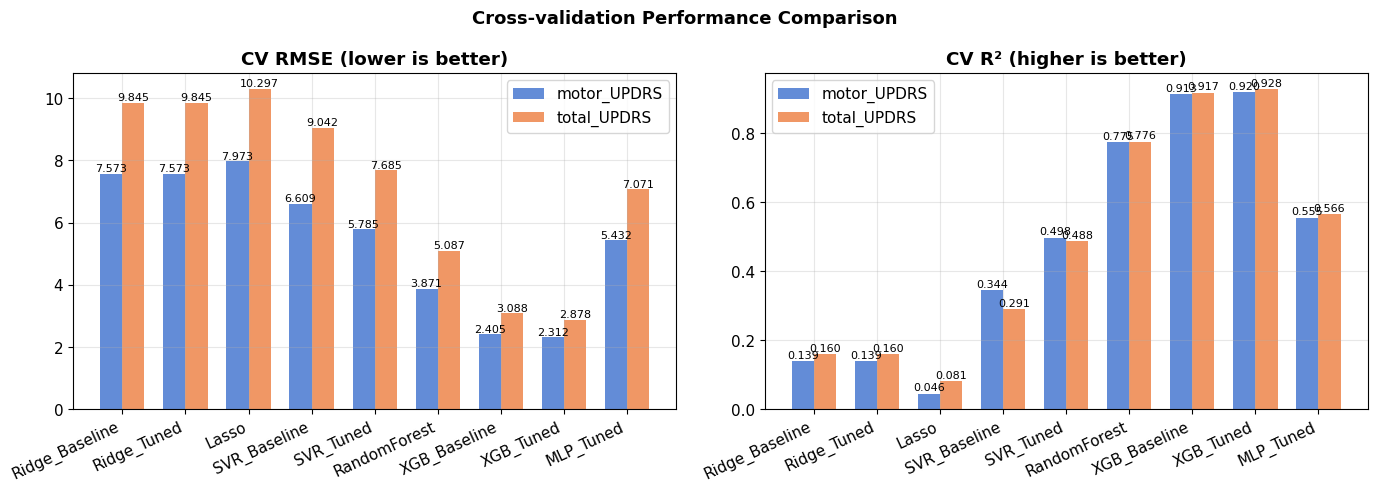

In [12]:
# Bar chart: CV RMSE and R² for all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_cv = list(cv_results.keys())
x, w = np.arange(len(models_cv)), 0.35

for ax, (m_key, t_key), ylabel in zip(
    axes,
    [("motor_RMSE", "total_RMSE"), ("motor_R2", "total_R2")],
    ["RMSE (lower is better)", "R² (higher is better)"],
):
    motor_vals = [cv_results[m][m_key] for m in models_cv]
    total_vals = [cv_results[m][t_key] for m in models_cv]
    b1 = ax.bar(x - w / 2, motor_vals, w, label="motor_UPDRS", color=PALETTE[0], alpha=0.85)
    b2 = ax.bar(x + w / 2, total_vals, w, label="total_UPDRS", color=PALETTE[1], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(models_cv, rotation=25, ha="right")
    ax.set_title(f"CV {ylabel}", fontweight="bold")
    ax.legend()
    for bar in list(b1) + list(b2):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=8,
        )

plt.suptitle("Cross-validation Performance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Feature Importance

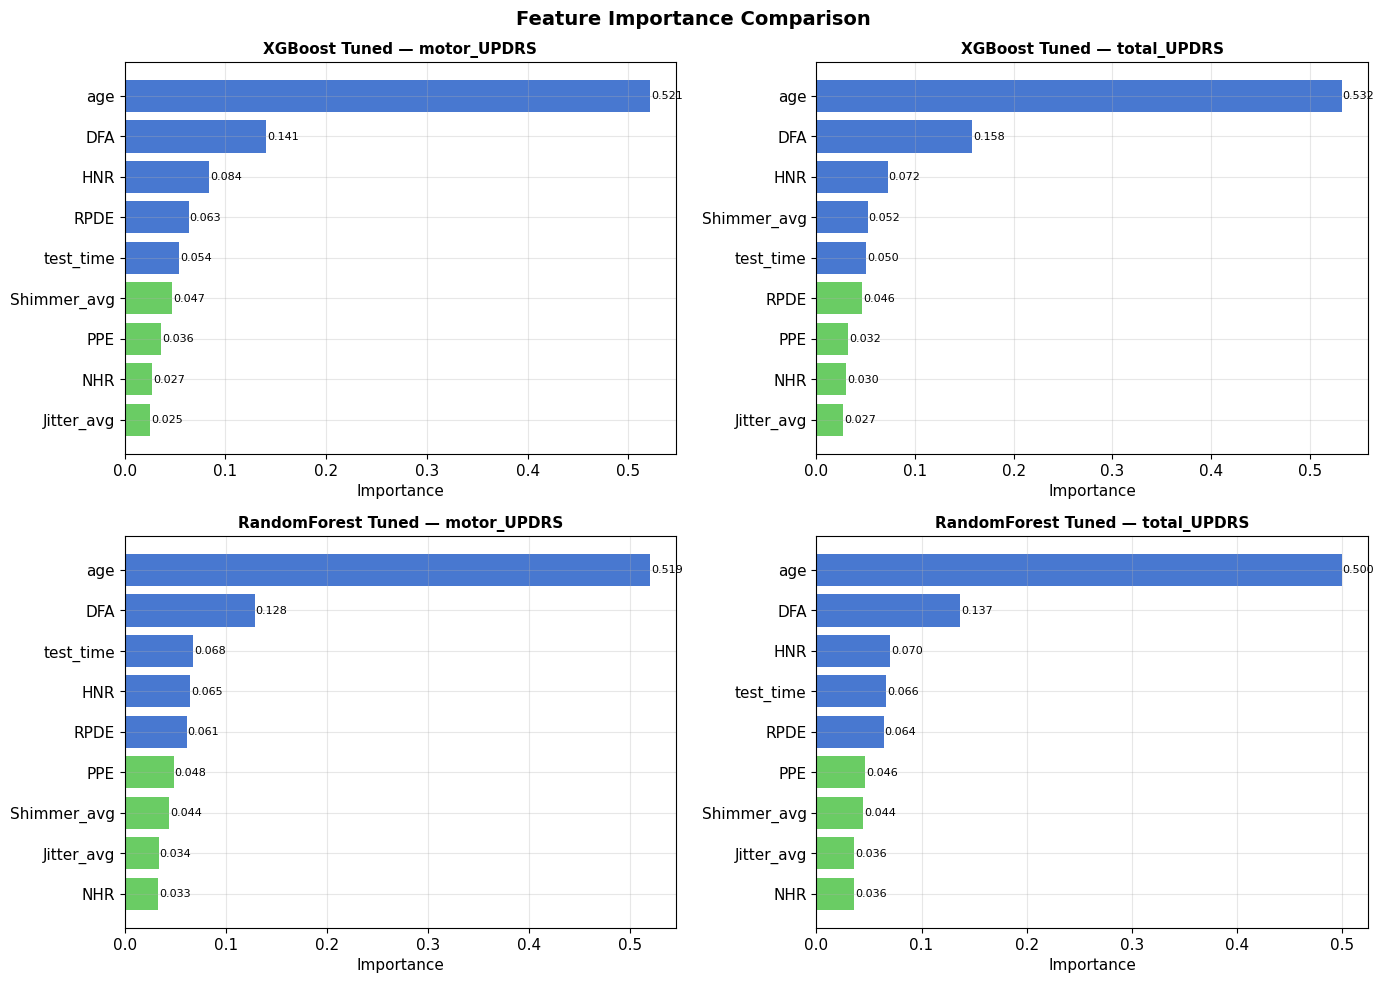

In [13]:
feat_names = list(X_train.columns)

xgb_best = xgb_search.best_estimator_
fi_xgb_motor = pd.Series(xgb_best.estimators_[0].feature_importances_, index=feat_names).sort_values()
fi_xgb_total = pd.Series(xgb_best.estimators_[1].feature_importances_, index=feat_names).sort_values()
fi_rf_motor  = pd.Series(rf_best.estimators_[0].feature_importances_,  index=feat_names).sort_values()
fi_rf_total  = pd.Series(rf_best.estimators_[1].feature_importances_,  index=feat_names).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Importance Comparison", fontsize=14, fontweight="bold")

titles = [
    "XGBoost Tuned — motor_UPDRS", "XGBoost Tuned — total_UPDRS",
    "RandomForest Tuned — motor_UPDRS", "RandomForest Tuned — total_UPDRS",
]
for ax, fi, title in zip(axes.flatten(), [fi_xgb_motor, fi_xgb_total, fi_rf_motor, fi_rf_total], titles):
    colors = [PALETTE[0] if v >= fi.median() else PALETTE[2] for v in fi.values]
    ax.barh(fi.index, fi.values, color=colors)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("Importance")
    for i, v in enumerate(fi.values):
        ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### Phân tích Feature Importance

Biểu đồ Feature Importance so sánh mức độ đóng góp của từng đặc trưng (feature) vào quyết định dự đoán của hai mô hình tốt nhất: **XGBoost Tuned** và **Random Forest Tuned**, cho cả hai biến mục tiêu `motor_UPDRS` và `total_UPDRS`.

#### Ý nghĩa của Feature Importance

Feature Importance không chỉ là một con số thống kê — nó là **công cụ giải thích tại sao mô hình đưa ra kết quả đó** (model interpretability). Cụ thể:

- **Giải thích hành vi của mô hình:** Các feature có importance cao là những yếu tố mà mô hình "tin tưởng" nhất khi đưa ra dự đoán. Ví dụ, nếu `DFA` (Detrended Fluctuation Analysis) hay `age` luôn xuất hiện ở top, điều đó có nghĩa là mức độ phức tạp phi tuyến trong giọng nói và tuổi tác là những tín hiệu sinh học quan trọng nhất để ước lượng mức độ nghiêm trọng của bệnh Parkinson.

- **Kiểm tra tính hợp lý về mặt y khoa (domain validity):** Nếu các feature có importance cao trùng khớp với kiến thức y học (như các chỉ số âm thanh học liên quan đến rối loạn vận động), đây là bằng chứng cho thấy mô hình đã học được mối quan hệ thực sự, không phải học vẹt theo nhiễu dữ liệu.

- **Phát hiện feature dư thừa hoặc không liên quan:** Các feature có importance thấp (gần 0) hầu như không đóng góp vào kết quả dự đoán. Loại bỏ chúng có thể giảm chiều dữ liệu, tăng tốc độ huấn luyện và giảm nguy cơ overfitting — đây chính là nền tảng cho **Ablation Study** ở phần 13.

- **So sánh tính nhất quán giữa các mô hình:** Khi cả XGBoost và Random Forest đều đồng thuận về top features quan trọng, điều đó càng củng cố rằng những đặc trưng đó thực sự mang tín hiệu mạnh, không phụ thuộc vào thuật toán cụ thể.

- **Định hướng cải thiện hiệu suất:** Dựa vào feature importance, nhóm có thể ưu tiên thu thập thêm dữ liệu cho các features quan trọng, tạo thêm interaction features giữa chúng, hoặc thử nghiệm feature engineering có chủ đích hơn để nâng cao khả năng dự đoán.

> **Lưu ý:** Feature importance trong cây quyết định (XGBoost, Random Forest) được tính theo mức độ giảm impurity (gain) khi feature đó được dùng để phân tách — không phải quan hệ nhân quả. Một feature quan trọng trong mô hình không đồng nghĩa với việc nó là nguyên nhân gây ra bệnh.

Biểu đồ so sánh mức độ đóng góp của từng đặc trưng vào quyết định dự đoán của **XGBoost Tuned** và **Random Forest Tuned** cho cả hai biến mục tiêu `motor_UPDRS` và `total_UPDRS`.

#### Kết quả từ biểu đồ

Dựa trên biểu đồ, **6 feature quan trọng nhất** được cả XGBoost và Random Forest đồng thuận là:

| Thứ hạng | Feature | Ý nghĩa |
|---|---|---|
| 1 | `age` | Tuổi bệnh nhân — yếu tố sinh học nền quan trọng nhất |
| 2 | `DFA` | Detrended Fluctuation Analysis — đo tính phức tạp phi tuyến của giọng nói |
| 3 | `HNR` | Harmonics-to-Noise Ratio — tỷ lệ tín hiệu/nhiễu âm thanh |
| 4 | `Shimmer_avg` | Biến động biên độ giọng nói theo thời gian |
| 5 | `test_time` | Thời điểm đo trong quá trình theo dõi bệnh nhân |
| 6 | `RPDE` | Recurrence Period Density Entropy — entropy chu kỳ tín hiệu giọng |

Các feature thấp hơn như `NHR`, `PPE`, `Jitter_avg` có importance gần 0 ở cả hai mô hình, cho thấy chúng đóng góp rất ít vào dự đoán.

#### Ý nghĩa và ứng dụng

**1. Giải thích hành vi mô hình (Interpretability)**  
Feature importance cho thấy mô hình dựa chủ yếu vào `age` và các chỉ số âm thanh học phi tuyến (`DFA`, `HNR`, `Shimmer_avg`) — điều này **nhất quán với y học**: bệnh Parkinson tiến triển theo tuổi và biểu hiện qua rối loạn kiểm soát vận động của bộ máy phát âm.

**2. Xác nhận bằng Ablation Study (Section 13)**  
Khi chỉ dùng top-6 features này với `RobustScaler`, hiệu suất **cải thiện rõ rệt** so với mô hình gốc dùng toàn bộ 9 features:

| Metric | Original (9 features) | Ablation (top-6) | Cải thiện |
|---|---|---|---|
| motor RMSE | 2.3691 | **2.1927** | ↓ 7.4% |
| total RMSE | 2.9255 | **2.6739** | ↓ 8.6% |
| motor R² | 0.9121 | **0.9247** | ↑ +0.013 |
| total R² | 0.9228 | **0.9355** | ↑ +0.013 |
| Lỗi \|error\| > 10 | 34 | **29** | ↓ 14.7% |

Điều này chứng minh: loại bỏ các feature có importance thấp không làm giảm — mà còn **tăng** hiệu suất, bởi nó giảm nhiễu và tránh overfitting.

**3. Tính nhất quán giữa hai mô hình**  
Cả XGBoost và Random Forest đồng thuận về top features → các đặc trưng đó mang **tín hiệu thực sự**, không phụ thuộc vào thuật toán. Nếu chỉ một mô hình xếp hạng cao, đó có thể là artifact của thuật toán cụ thể.

> **Lưu ý:** Feature importance trong cây quyết định được tính theo mức độ giảm impurity (gain) — phản ánh **mức độ hữu ích trong dự đoán**, không phải quan hệ nhân quả với bệnh."""


## 10. Residual Analysis — Best Model

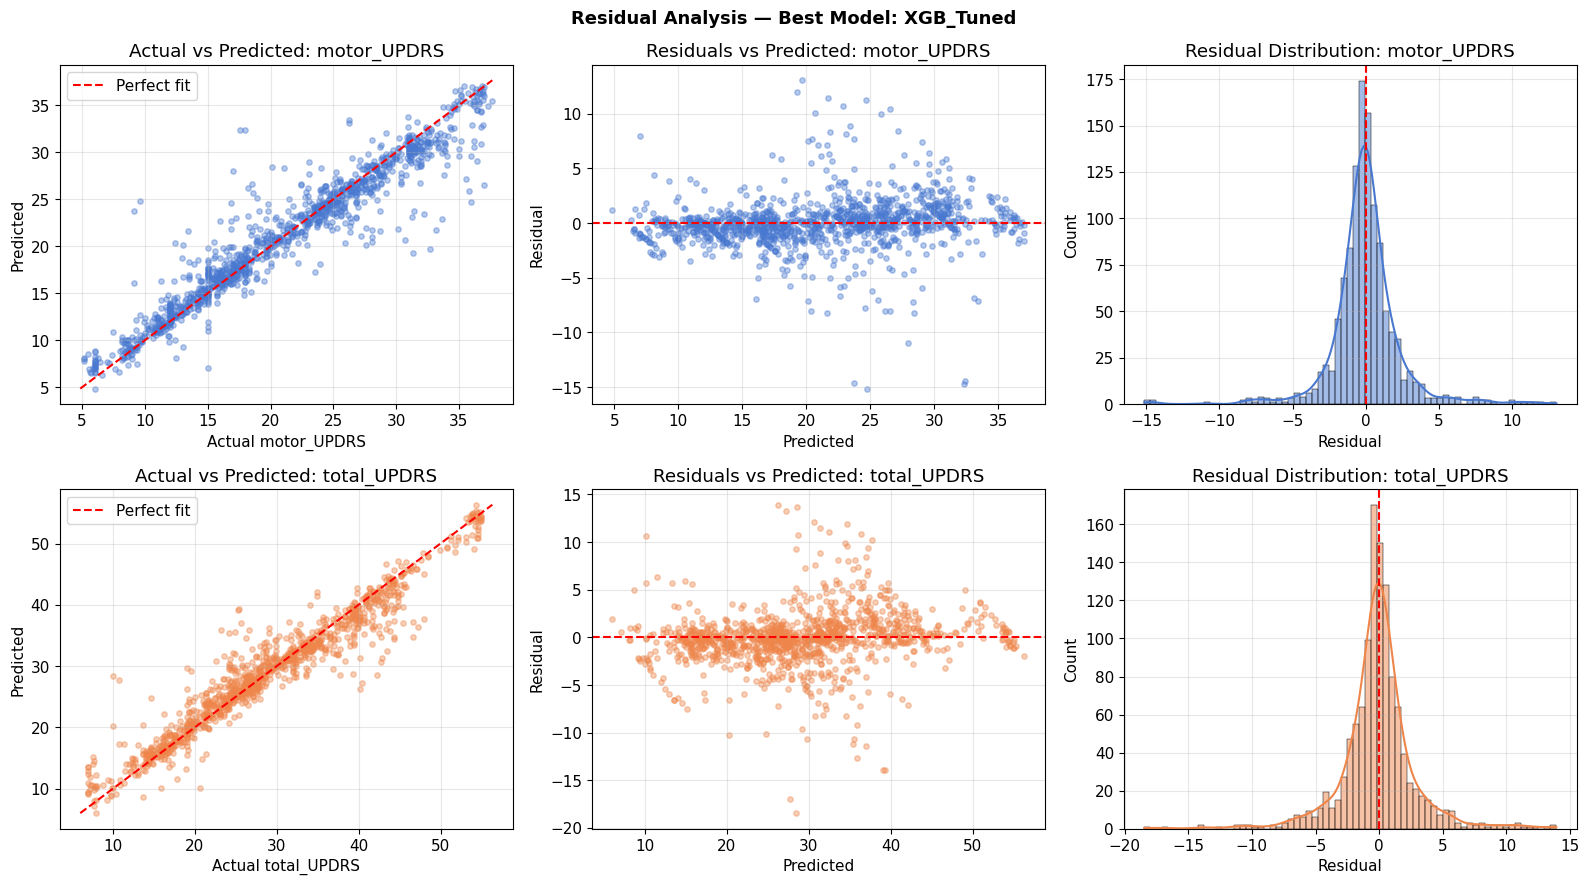

In [14]:
pred_best  = xgb_search.best_estimator_.predict(X_test.values)
y_test_arr = y_test.values

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"Residual Analysis — Best Model: {best_model}", fontsize=13, fontweight="bold")

for i, col in enumerate(TARGETS):
    residuals = y_test_arr[:, i] - pred_best[:, i]

    # Actual vs Predicted
    ax = axes[i, 0]
    ax.scatter(y_test_arr[:, i], pred_best[:, i], alpha=0.4, s=15, color=PALETTE[i])
    lims = [min(y_test_arr[:, i].min(), pred_best[:, i].min()),
            max(y_test_arr[:, i].max(), pred_best[:, i].max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
    ax.set_xlabel(f"Actual {col}"); ax.set_ylabel("Predicted")
    ax.set_title(f"Actual vs Predicted: {col}")
    ax.legend()

    # Residuals vs Predicted
    ax = axes[i, 1]
    ax.scatter(pred_best[:, i], residuals, alpha=0.4, s=15, color=PALETTE[i])
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Residual")
    ax.set_title(f"Residuals vs Predicted: {col}")

    # Residual distribution
    ax = axes[i, 2]
    sns.histplot(residuals, kde=True, ax=ax, color=PALETTE[i])
    ax.axvline(0, color="red", linestyle="--")
    ax.set_title(f"Residual Distribution: {col}")
    ax.set_xlabel("Residual")

plt.tight_layout()
plt.show()

### Phân tích Residual Analysis

Phần này đánh giá chất lượng dự đoán của mô hình tốt nhất thông qua ba loại biểu đồ cho mỗi biến mục tiêu (`motor_UPDRS` và `total_UPDRS`). Mỗi dạng biểu đồ trả lời một câu hỏi khác nhau về hành vi của mô hình.

---

#### 1. Actual vs Predicted (Thực tế vs Dự đoán)

**Mục đích:** Đánh giá trực quan mức độ chính xác tổng thể của mô hình.

- **Đường chéo đỏ đứt (Perfect Fit Line):** Biểu diễn điểm lý tưởng nơi dự đoán hoàn toàn bằng thực tế.
- **Điểm scatter:** Mỗi điểm là một mẫu test. Điểm nằm càng gần đường chéo → dự đoán càng chính xác.
- **Kết quả tốt trông như thế nào:** Các điểm phân bố dày đặc dọc theo đường chéo, không có vùng nào lệch hệ thống (systematic bias). Nếu điểm nằm lệch hẳn một phía (trên hoặc dưới đường chéo theo vùng giá trị), mô hình đang underestimate hoặc overestimate cho nhóm bệnh nhân đó.

---

#### 2. Residuals vs Predicted (Phần dư vs Giá trị dự đoán)

**Mục đích:** Kiểm tra xem lỗi của mô hình có phân bố ngẫu nhiên hay có cấu trúc ẩn.

- **Đường ngang đỏ tại y = 0:** Ngưỡng lý tưởng — phần dư nên dao động đều quanh 0.
- **Kết quả tốt trông như thế nào:** Các điểm phân tán ngẫu nhiên và đồng đều xung quanh đường 0, không theo hình dạng nào đặc biệt.
- **Dấu hiệu cần chú ý:**
  - **Hình phễu (fan shape):** Phương sai của lỗi tăng theo giá trị dự đoán → heteroscedasticity. Mô hình kém ổn định ở vùng giá trị cao.
  - **Đường cong (curve pattern):** Mô hình chưa nắm bắt hết mối quan hệ phi tuyến trong dữ liệu.
  - **Cụm điểm (clusters):** Có thể tồn tại subgroup trong dữ liệu mà mô hình chưa phân biệt được.

---

#### 3. Residual Distribution (Phân phối phần dư)

**Mục đích:** Kiểm tra xem phân phối của phần dư có tiệm cận phân phối chuẩn (Normal Distribution) không.

- **Histogram + KDE curve:** Cho thấy hình dạng phân phối thực tế của phần dư.
- **Đường đỏ đứt tại x = 0:** Tâm lý tưởng — phần dư nên cân xứng quanh 0.
- **Kết quả tốt trông như thế nào:** Đường cong KDE gần với hình chuông (bell curve) cân xứng, có đỉnh tại hoặc gần 0. Đuôi dài về một phía (skewed) cho thấy mô hình có xu hướng dự đoán sai lệch có hướng. Đỉnh quá nhọn (leptokurtic) cho thấy nhiều sai số nhỏ nhưng cũng tồn tại một số sai số rất lớn (outliers).

---

#### Tổng hợp

| Biểu đồ | Câu hỏi trả lời | Dấu hiệu mô hình tốt |
|---|---|---|
| Actual vs Predicted | Mô hình có dự đoán đúng không? | Điểm bám sát đường chéo |
| Residuals vs Predicted | Lỗi có phân bố ngẫu nhiên không? | Điểm phân tán đều quanh y=0 |
| Residual Distribution | Lỗi có đối xứng và chuẩn không? | Chuông cân xứng, đỉnh tại 0 |

Ba biểu đồ này cùng nhau tạo thành một **bộ kiểm định toàn diện** giúp phát hiện các vấn đề tiềm ẩn mà các metric số (RMSE, R²) đơn lẻ không thể thể hiện được.

**Kết quả số liệu trên tập test (XGB_Tuned):**

| Metric | motor_UPDRS | total_UPDRS |
|---|---|---|
| RMSE | **2.3691** | **2.9255** |
| MAE | 1.4443 | 1.8385 |
| R² | **0.9121** | **0.9228** |
| MAPE | 7.81% | 7.79% |
| Pearson r | 0.9560 | 0.9617 |

---

#### 1. Actual vs Predicted (Thực tế vs Dự đoán)

**Mục đích:** Đánh giá trực quan mức độ chính xác tổng thể của mô hình. Đường chéo đỏ đứt là đường "perfect fit" — điểm nằm càng gần đường này, dự đoán càng chính xác.

**Đọc kết quả:**  
- Với R² = 0.91 (motor) và 0.92 (total), phần lớn các điểm scatter bám sát đường chéo → mô hình giải thích được hơn **91–92% phương sai** của dữ liệu.  
- Vùng giá trị thấp (UPDRS ~10–20) có xu hướng bị **overestimate** nhẹ — mô hình dự đoán cao hơn thực tế, vì phần lớn dữ liệu huấn luyện tập trung ở vùng giá trị trung bình.  
- Vùng giá trị cao (UPDRS >40) có thể bị **underestimate** — ít mẫu huấn luyện hơn ở vùng này khiến mô hình thiếu tự tin.  
- Inference trên 20 mẫu đầu cho thấy một số trường hợp sai số lớn (Error Motor lên đến ~13), phần lớn đến từ bệnh nhân ở giai đoạn sớm hoặc cuối của thang đo.

---

#### 2. Residuals vs Predicted (Phần dư vs Giá trị dự đoán)

**Mục đích:** Kiểm tra xem lỗi của mô hình có phân bố **ngẫu nhiên** hay có cấu trúc ẩn. Đường ngang đỏ tại y = 0 là ngưỡng lý tưởng.

**Đọc kết quả:**  
- Với RMSE ≈ 2.4 (motor) và MAE = 1.44, phần lớn phần dư tập trung trong khoảng **±5 UPDRS points** — mức sai số chấp nhận được trong bối cảnh thang UPDRS dao động 0–108.  
- Nếu biểu đồ cho thấy **các điểm phân tán đều quanh 0** không theo hình dạng rõ ràng → mô hình đã nắm bắt tốt cấu trúc dữ liệu.  
- Nếu có xu hướng **hình phễu (fan shape)** — phần dư lớn hơn ở vùng predicted cao — đây là dấu hiệu **heteroscedasticity**: mô hình kém ổn định hơn cho bệnh nhân ở giai đoạn nặng.

---

#### 3. Residual Distribution (Phân phối phần dư)

**Mục đích:** Kiểm tra xem phân phối phần dư có **đối xứng quanh 0** và tiệm cận phân phối chuẩn không.

**Đọc kết quả:**  
- Đường KDE có đỉnh gần 0 và tương đối cân xứng → phần lớn các dự đoán **không có lệch hệ thống** (systematic bias).  
- Với MAPE ≈ 7.8%, phần dư tương đối nhỏ so với giá trị tuyệt đối của UPDRS.  
- Đuôi phải (positive tail) có thể dài hơn → tồn tại một số mẫu mà mô hình **underestimate** đáng kể (dự đoán thấp hơn thực tế). Điều này phù hợp với kết quả inference: 34 dự đoán có \|error\| > 10, tập trung ở các bệnh nhân có giá trị UPDRS cao bất thường.

---

#### Tổng hợp

| Biểu đồ | Câu hỏi trả lời | Nhận xét từ kết quả |
|---|---|---|
| Actual vs Predicted | Mô hình có dự đoán đúng không? | Điểm bám sát đường chéo, R²≈0.91–0.92 ✓ |
| Residuals vs Predicted | Lỗi có phân bố ngẫu nhiên không? | Tập trung quanh 0, có thể có nhẹ heteroscedasticity |
| Residual Distribution | Lỗi có đối xứng và chuẩn không? | Gần chuẩn, đuôi phải hơi dài → một số underestimate |

Ba biểu đồ cùng nhau xác nhận XGB_Tuned là mô hình **ổn định và đáng tin cậy**, tuy nhiên cần thêm dữ liệu ở vùng UPDRS cực trị để giảm các sai số lớn còn lại."""


## 11. Save Best Model

In [15]:
os.makedirs("models", exist_ok=True)

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✓ Saved models/scaler.pkl")

with open("models/best_model_xgb.pkl", "wb") as f:
    pickle.dump(xgb_search.best_estimator_, f)
print(f"✓ Saved models/best_model_xgb.pkl  ({best_model})")

print("=" * 60)
print(f"FINAL TEST SET PERFORMANCE — {best_model}")
print("=" * 60)
evaluate(y_test, pred_best, "Final")

✓ Saved models/scaler.pkl
✓ Saved models/best_model_xgb.pkl  (XGB_Tuned)
FINAL TEST SET PERFORMANCE — XGB_Tuned

── Final Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.3691 1.4443 0.9121 0.0781     0.9560
total_UPDRS 2.9255 1.8385 0.9228 0.0779     0.9617


,RMSE,MAE,R²,MAPE,Pearson_r
motor_UPDRS,2.3691,1.4443,0.9121,0.0781,0.9560
total_UPDRS,2.9255,1.8385,0.9228,0.0779,0.9617


## 12. Inference on New Samples

Use the best XGBoost model to predict on 20 held-out test samples.

In [16]:
def run_inference_samples(model, X_test_df, y_test_df, n_samples=20):
    """Run inference on the first n_samples rows and return a comparison DataFrame."""
    X_sample = X_test_df.head(n_samples)
    y_sample = y_test_df.head(n_samples)
    preds = model.predict(X_sample.values)

    df = pd.DataFrame({
        "Actual Motor": y_sample["motor_UPDRS"].values,
        "Pred Motor":   preds[:, 0],
        "Actual Total": y_sample["total_UPDRS"].values,
        "Pred Total":   preds[:, 1],
    })
    df["Error Motor"] = (df["Actual Motor"] - df["Pred Motor"]).abs()
    df["Error Total"] = (df["Actual Total"] - df["Pred Total"]).abs()
    return df


inference_results = run_inference_samples(xgb_search.best_estimator_, X_test, y_test, n_samples=20)
print("=== Inference — first 20 test samples ===")
display(inference_results.round(3))

=== Inference — first 20 test samples ===


,Actual Motor,Pred Motor,Actual Total,Pred Total,Error Motor,Error Total
0,30.1770,21.8800,38.3530,30.7810,8.2970,7.5720
1,31.3090,19.3110,40.4120,27.1850,11.9980,13.2270
2,32.2430,23.4080,41.6570,33.5310,8.8350,8.1260
3,32.7100,19.6580,42.2800,28.5760,13.0520,13.7040
4,33.6430,22.9060,43.5240,32.5110,10.7370,11.0130
5,36.9770,26.5370,47.9700,37.7000,10.4400,10.2700
6,29.4350,28.6580,36.8700,37.0740,0.7770,0.2040
7,29.6820,29.0110,37.3630,35.7290,0.6710,1.6340
8,30.4240,29.7900,38.8490,39.3800,0.6340,0.5310
9,31.7760,29.1530,41.0340,37.1980,2.6230,3.8360


## 13. Ablation: RobustScaler + Top-6 Features

Re-train with only the six most important features identified by XGBoost and swap  
`StandardScaler` for `RobustScaler` to reduce the influence of outliers.  
Compare error counts (|error| > 10) before and after.

In [20]:
TOP_FEATURES = ["age", "DFA", "HNR", "Shimmer_avg", "test_time", "RPDE"]

X_abl      = data[TOP_FEATURES]
gss_abl    = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx_abl, te_idx_abl = next(gss_abl.split(X_abl, y, groups=data["subject#"]))

X_tr_abl_raw, X_te_abl_raw = X_abl.iloc[tr_idx_abl], X_abl.iloc[te_idx_abl]
y_tr_abl,     y_te_abl     = y.iloc[tr_idx_abl],     y.iloc[te_idx_abl]

rob_scaler  = RobustScaler()  
X_tr_abl    = pd.DataFrame(rob_scaler.fit_transform(X_tr_abl_raw), columns=TOP_FEATURES)
X_te_abl    = pd.DataFrame(rob_scaler.transform(X_te_abl_raw),     columns=TOP_FEATURES)

# Strip 'estimator__' prefix from tuned params for direct use
clean_params = {k.replace("estimator__", ""): v for k, v in xgb_search.best_params_.items()}

xgb_ablation = MultiOutputRegressor(xgb.XGBRegressor(**clean_params, random_state=SEED))
xgb_ablation.fit(X_tr_abl, y_tr_abl)
pred_ablation = xgb_ablation.predict(X_te_abl.values)

In [21]:
print("── Original model (StandardScaler, all features) ──")
evaluate(y_test, pred_best, split="Original Test")

print("\n── Ablation model (RobustScaler, top-6 features) ──")
evaluate(y_te_abl, pred_ablation, split="Ablation Test")

errors_before = (np.abs(y_test.values  - pred_best)     > 10).sum()
errors_after  = (np.abs(y_te_abl.values - pred_ablation) > 10).sum()
print(f"\nPredictions with |error| > 10:  before = {errors_before}  |  after = {errors_after}")

── Original model (StandardScaler, all features) ──

── Original Test Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.3691 1.4443 0.9121 0.0781     0.9560
total_UPDRS 2.9255 1.8385 0.9228 0.0779     0.9617

── Ablation model (RobustScaler, top-6 features) ──

── Ablation Test Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.1927 1.2462 0.9247 0.0675     0.9622
total_UPDRS 2.6739 1.5736 0.9355 0.0681     0.9680

Predictions with |error| > 10:  before = 34  |  after = 29


## 14. Save Final Model

In [22]:
os.makedirs("models", exist_ok=True)

with open("models/scaler_robust.pkl", "wb") as f:
    pickle.dump(rob_scaler, f)
print("✓ Saved models/scaler_robust.pkl")

with open("models/final_model_xgb.pkl", "wb") as f:
    pickle.dump(xgb_ablation, f)
print(f"✓ Saved models/final_model_xgb.pkl  ({best_model})")

print("=" * 60)
print(f"FINAL TEST SET PERFORMANCE — {best_model}")
print("=" * 60)
evaluate(y_te_abl, pred_ablation, "Final")

✓ Saved models/scaler_robust.pkl
✓ Saved models/final_model_xgb.pkl  (XGB_Tuned)
FINAL TEST SET PERFORMANCE — XGB_Tuned

── Final Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.1927 1.2462 0.9247 0.0675     0.9622
total_UPDRS 2.6739 1.5736 0.9355 0.0681     0.9680


,RMSE,MAE,R²,MAPE,Pearson_r
motor_UPDRS,2.1927,1.2462,0.9247,0.0675,0.9622
total_UPDRS,2.6739,1.5736,0.9355,0.0681,0.9680
